In [1]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Extracting ZIP
import zipfile
zip_path = "/content/drive/My Drive/Sentiment.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np

import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Step 2: Load Dataset
df = pd.read_csv("/content/dataset/data.csv")
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [6]:
# Step 3: Check Dataset Structure
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.info()

Shape: (5842, 2)

Columns:
Index(['Sentence', 'Sentiment'], dtype='object')

Data Types:
Sentence     object
Sentiment    object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [7]:
# Step 4: Check Missing Values
df.isnull().sum()

,0
Sentence,0
Sentiment,0


In [8]:
# Step 5: Remove Missing Values
df = df.dropna()
print("Missing values removed")

df.isnull().sum()

Missing values removed


,0
Sentence,0
Sentiment,0


In [9]:
# Step 6: Check Sentiment Class Distribution
df['Sentiment'].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


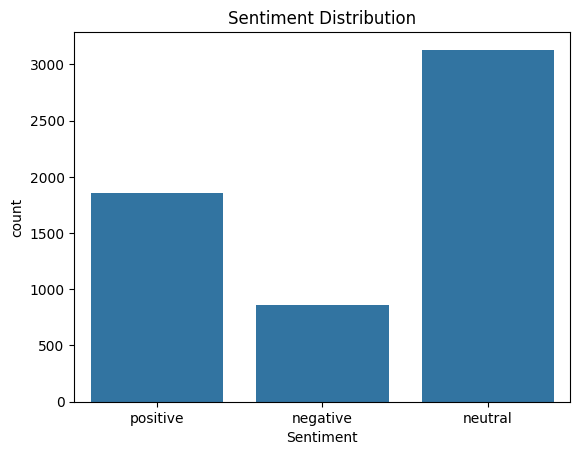

In [10]:
# Step 7: Visualize Class Balance
sns.countplot(
    x=df['Sentiment']
)

plt.title("Sentiment Distribution")
plt.show()

In [11]:
# Step 8: Convert Multi-Class Sentiment Into Binary Sentiment
df = df[df['Sentiment'] != "neutral"]
df['Sentiment'].value_counts()

,count
Sentiment,
positive,1852
negative,860


In [12]:
# Step 9: Encode Target Labels
df['Sentiment'] = df['Sentiment'].map(
    {
        "negative":0,
        "positive":1
    }
)

df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",0
2,"For the last quarter of 2010 , Componenta 's n...",1
5,$SPY wouldn't be surprised to see a green close,1
6,Shell's $70 Billion BG Deal Meets Shareholder ...,0


In [13]:
# Step 10: Download NLTK Resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [14]:
# Step 11: Create Text Preprocessing Pipeline
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # remove special characters
    text = re.sub(
        '[^a-zA-Z]',
        ' ',
        text
    )
    # lowercase
    text = text.lower()
    # tokenize
    words = word_tokenize(text)
    # remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [16]:
nltk.download('punkt_tab', quiet=True)
# Step 12: Apply NLP Cleaning On Text Data
df['Clean_Sentence'] = df['Sentence'].apply(clean_text)
df[['Sentence','Clean_Sentence']].head()

,Sentence,Clean_Sentence
0,The GeoSolutions technology will leverage Bene...,geosolutions technology leverage benefon gps s...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",esi low bk real possibility
2,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale doubled eur e...
5,$SPY wouldn't be surprised to see a green close,spy surprised see green close
6,Shell's $70 Billion BG Deal Meets Shareholder ...,shell billion bg deal meet shareholder skepticism


In [17]:
# Step 13: Separate Input Text And Target Labels
X = df['Clean_Sentence']
y = df['Sentiment']

print(X.shape)
print(y.shape)

(2712,)
(2712,)


In [18]:
# Step 14: Split Dataset Into Training And Testing Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(2169,)
(543,)


In [19]:
# Step 15: Convert Text Into Mathematical Arrays Using TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(2169, 5000)


In [20]:
# Step 16: Train Naive Bayes Classification Model
model = MultinomialNB()
model.fit(
    X_train_tfidf,
    y_train
)

print("Model Training Completed")

Model Training Completed


In [21]:
# Step 17: Make Predictions On Test Data
y_pred = model.predict(
    X_test_tfidf
)

y_pred[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 0, 1])

In [22]:
# Step 18: Evaluate Model Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.7329650092081031


In [23]:
# Step 19: Classification Performance Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.19      0.31       172
           1       0.72      0.99      0.83       371

    accuracy                           0.73       543
   macro avg       0.79      0.59      0.57       543
weighted avg       0.77      0.73      0.67       543



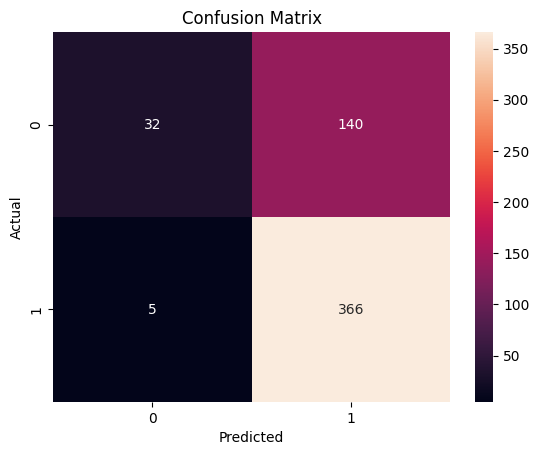

In [24]:
# Step 20: Confusion Matrix Visualization
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
# Step 21: Test Model With New Review
def predict_sentiment(review):
    cleaned = clean_text(review)
    vector = tfidf.transform(
        [cleaned]
    )

    prediction = model.predict(
        vector
    )
    if prediction[0] == 1:
        return "Positive"
    else:
        return "Negative"

predict_sentiment(
    "This product is amazing and I really love it"
)

'Positive'